# Global density constraints: real and imaginary part of the material density

Global bound with power conservation constraints (real and imaginary part, shared projectors) and two general constraints on the inferred material density
$$\rho_i = \frac{Z_s I_i}{u_i}, \qquad u = V - Z_0 I .$$
Multiplying by $|u_i|^2$ gives quadratic constraints in $I$:
$$\sum_i w_i \operatorname{Im}\left[Z_s I_i u_i^*\right] = 0 \quad (\operatorname{Im}\rho = 0),\qquad
\sum_i w_i \left(\operatorname{Re}\left[Z_s I_i u_i^*\right] - p\,|u_i|^2\right) = 0 \quad (\operatorname{Re}\rho = p),$$
with $p = 0.9$.

In [259]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

# conda clean --all

In [260]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [261]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
# Zs = 1 / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
# Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix
Lmat = np.loadtxt(r"Lmat_patch21ka1.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

# R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = np.loadtxt(r"R0_patch21ka1.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

# X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = np.loadtxt(r"X0_patch21ka1.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

# Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = np.loadtxt(r"V_patch21ka1.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ Vinc)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Rmat = np.real(Zmat) # rezistivity matrix

Vzero = np.zeros((Ndes,), dtype=complex) # zero vector

Obj = -0.5 * R0
obj = Vzero/2
obj0 = 0

def evalObj(Ivec):
    return(-np.real(Ivec.conj().T @ Obj @ Ivec) + 2*np.real(Ivec.conj().T @ obj) + obj0)

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObj(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  233
Objective for full plate: 4.114174e-02 W


## QCQP with global power conservation (real + imaginary part)

Shared constraints $\operatorname{Re}\left(-I^H A_1 P_j I + 2 I^H P_j^H e\right) = 0$ with $U = j Z_\mathrm{tot}/Z_s$, $A_1 = U^H = -j Z_\mathrm{tot}^*/Z_s^*$, $e = jV/(2Z_s)$ (so $U I = 2e$) and projectors $P_j = Z_s^* p_j I$, which gives
$$\operatorname{Re}\left(j p_j^* I^H (V - Z_\mathrm{tot} I)\right) = 0 ,$$
i.e. $p_1 = 1$: reactive power, $p_2 = j$: real power conservation.

In [262]:
Umat = -1j * Ztot.conj()/np.conj(Zs)   # A1 = U^H with U = j Ztot (Ztot symmetric)
eVec = 1j * Vinc / 2/Zs

Pdiags = np.conj(Zs) * np.column_stack([np.ones(Ndes), 1j*np.ones(Ndes)]).astype(complex)  # global: Im and Re part
Plist = [sp.diags(Pdiags[:, i]) for i in range(Pdiags.shape[1])]

Bmat = Obj
bVec = obj
beta = obj0

def projRes(I, p):
    # residual of the shared constraint with projector diagonal p
    return np.real(-I.conj() @ (Umat @ (p*I)) + 2*I.conj() @ (np.conj(p)*eVec))

print("power conservation residuals at full plate:", [f"{projRes(Ifull, Pdiags[:, k]):.2e}" for k in range(Pdiags.shape[1])])

power conservation residuals at full plate: ['2.22e-16', '2.91e-16']


## Density constraints

Imaginary part, $\sum_i w_i \operatorname{Im}\left[Z_s I_i u_i^*\right] = \operatorname{Re}\left(-I^H B_\mathrm{Im} I + 2 I^H s_\mathrm{Im}\right)$:
$$B_\mathrm{Im} = -\operatorname{Sym}\left(j Z_s Z_0^H D_w\right),\qquad s_\mathrm{Im} = \tfrac{j}{2} Z_s^* D_w V .$$
Real part, $\sum_i w_i \left(\operatorname{Re}\left[Z_s I_i u_i^*\right] - p|u_i|^2\right) = \operatorname{Re}\left(-I^H B_\mathrm{Re} I + 2 I^H s_\mathrm{Re}\right) + c_\mathrm{Re}$:
$$B_\mathrm{Re} = \operatorname{Sym}\left(Z_s Z_0^H D_w\right) + p\, Z_0^H D_w Z_0,\qquad
s_\mathrm{Re} = \tfrac{1}{2} Z_s^* D_w V + p\, Z_0^H D_w V,\qquad c_\mathrm{Re} = -p\, V^H D_w V .$$
Both are normalized by $\|B\|_2$. Check: the uniform design $\rho_i = p$, $(Z_s/p + Z_0) I = V$, satisfies both.

In [263]:
pDens = 0.9             # target real part of the material density
wDens = np.ones(Ndes)   # weights of the density sums
Dw = np.diag(wDens)

# imaginary part:  sum_i w_i Im[Zs I_i u_i^*] = 0
BdensIm = -Msym(1j*Zs * Z0.conj().T @ Dw)
sDensIm = 1j*np.conj(Zs) * wDens * Vinc / 2
cDensIm = 0.0
sc = np.linalg.norm(BdensIm, 2)
BdensIm, sDensIm, cDensIm = BdensIm/sc, sDensIm/sc, cDensIm/sc

# real part:  sum_i w_i (Re[Zs I_i u_i^*] - p |u_i|^2) = 0
BdensRe = Msym(Zs * Z0.conj().T @ Dw) + pDens * Z0.conj().T @ Dw @ Z0
sDensRe = np.conj(Zs) * wDens * Vinc / 2 + pDens * Z0.conj().T @ (wDens * Vinc)
cDensRe = -pDens * np.real(Vinc.conj() @ (wDens * Vinc))
sc = np.linalg.norm(BdensRe, 2)
BdensRe, sDensRe, cDensRe = BdensRe/sc, sDensRe/sc, cDensRe/sc

def genRes(I, B, s, c):
    return np.real(-I.conj() @ B @ I + 2*I.conj() @ s) + c

def complexDensity(I):
    return Zs*I/(Vinc - Z0 @ I)

Iunif = np.linalg.solve(Zs/pDens*np.eye(Ndes) + Z0, Vinc)   # uniform design rho = p
for name, I in [("full plate", Ifull), (f"uniform rho = {pDens}", Iunif)]:
    print(f"{name}: Im density residual {genRes(I, BdensIm, sDensIm, cDensIm):.2e}, "
          f"Re density residual {genRes(I, BdensRe, sDensRe, cDensRe):.2e}, "
          f"power conservation residuals {[f'{projRes(I, Pdiags[:, k]):.2e}' for k in range(Pdiags.shape[1])]}")

full plate: Im density residual 1.36e-19, Re density residual 4.03e-15, power conservation residuals ['2.22e-16', '2.91e-16']
uniform rho = 0.9: Im density residual -5.42e-20, Re density residual 1.32e-19, power conservation residuals ['-6.20e-06', '6.20e-06']


## Reference bounds: power conservation only, and power conservation + zero imaginary density

In [264]:
opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)

def reportBound(name, Q):
    x = Q.current_xstar
    print(f"{name}: bound {Q.current_dual:.6e} W, P(x*) {evalObj(x):.6e} W, Lagrange multipliers {Q.current_lags}")
    print(f"    min eigenvalue of A {np.min(np.linalg.eigvalsh(Msym(Q._get_total_A(Q.current_lags)))):.3e}, residuals at x*: power",
          [f"{projRes(x, Pdiags[:, k]):.2e}" for k in range(Pdiags.shape[1])],
          f"Im density {genRes(x, BdensIm, sDensIm, cDensIm):.2e}, Re density {genRes(x, BdensRe, sDensRe, cDensRe):.2e}")

# global power conservation only
QCQP_P = DenseSharedProjQCQP(Bmat, bVec, beta, Umat, eVec, Plist, verbose=0)
QCQP_P.solve_current_dual_problem(method='newton', init_lags=np.array([0., 1.]), opt_params=opt_params)
reportBound("power conservation", QCQP_P)

# global power conservation + zero weighted imaginary density
QCQP_PIm = DenseSharedProjQCQP(Bmat, bVec, beta, Umat, eVec, Plist,
                               B_j=[BdensIm], s_2j=[sDensIm], c_2j=[cDensIm], verbose=0)
QCQP_PIm.solve_current_dual_problem(method='newton', init_lags=np.array([0., 1., 0.]), opt_params=opt_params)
reportBound("power conservation + Im density", QCQP_PIm)
print(f"full plate {Pfull:.6e} W")

power conservation: bound 1.847944e+01 W, P(x*) 1.847944e+01 W, Lagrange multipliers [4.10994005e-05 8.83797883e-01]
    min eigenvalue of A 1.021e-02, residuals at x*: power ['1.48e-03', '-1.52e-07'] Im density 2.36e-07, Re density -2.69e-01
power conservation + Im density: bound 1.847944e+01 W, P(x*) 1.847942e+01 W, Lagrange multipliers [-5.36521999e-04  8.83220712e-01  3.61662960e+00]
    min eigenvalue of A 1.021e-02, residuals at x*: power ['1.37e-03', '2.38e-05'] Im density 2.23e-07, Re density -2.69e-01
full plate 4.114174e-02 W


## Dual problem: power conservation + Im and Re density

In [265]:
QCQP = DenseSharedProjQCQP(
    Bmat, bVec, beta,
    Umat, eVec,
    Plist,
    B_j=[BdensIm, BdensRe], s_2j=[sDensIm, sDensRe], c_2j=[cDensIm, cDensRe],
    verbose=1,
)

# Sym(A1 P_2) = Re(Ztot), so a positive multiplier on the real power constraint makes A dual feasible
lags_init = np.zeros(QCQP.get_number_constraints())
lags_init[1] = 1
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

t1 = time.time()
result = QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
print(f"bound: {result[0]:.6e} W, time: {time.time()-t1:.2f}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 4 A matrices and Fs vectors.
initial lags dual feasible: True
bound: 4.114431e-02 W, time: 0.26s, Lagrange multipliers: [ 1.05703985e+04  1.05706912e+04 -6.61845305e+07  6.21662586e+08]


In [266]:
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Ivec = QCQP.current_xstar
print(f"dual bound {QCQP.current_dual:.6e} W, P(x*) {evalObj(Ivec):.6e} W, full plate {Pfull:.6e} W, uniform rho = {pDens}: {evalObj(Iunif):.6e} W")
print("constraint residuals at x*:", [f"{projRes(Ivec, Pdiags[:, k]):.2e}" for k in range(Pdiags.shape[1])],
      f"Im {genRes(Ivec, BdensIm, sDensIm, cDensIm):.2e}, Re {genRes(Ivec, BdensRe, sDensRe, cDensRe):.2e}")

minimum eigenvalue of A: 4.527e+02
dual bound 4.114431e-02 W, P(x*) 4.114188e-02 W, full plate 4.114174e-02 W, uniform rho = 0.9: 4.114216e-02 W
constraint residuals at x*: ['-2.79e-08', '7.61e-11'] Im -4.45e-12, Re 3.92e-15


## GCD refinement

Generalized constraint descent on the projector constraints (`gcd.run_gcd`); the two density constraints stay as general constraints. Warm started from the global solution. `ortho_metric='euclidean'` converged much faster than the default `'hilbert_schmidt'` in `densityConstraintsImag.ipynb`.

In [267]:
import copy
from dolphindes.cvxopt.gcd import GCDHyperparameters

gcd_QCQP = copy.deepcopy(QCQP)

gcd_opt_params = OptimizationHyperparameters(
    opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0
)

gcd_params = GCDHyperparameters(
    max_proj_cstrt_num=30,
    max_gcd_iter_num=50,
    gcd_iter_period=5,
    gcd_tol=1e-3,
    orthonormalize=True,
    ortho_metric='euclidean',
    method='newton',
    opt_params=gcd_opt_params,
)

t = time.time()
gcd_QCQP.run_gcd(gcd_params=gcd_params)
print(f"gcd optimization took time {time.time()-t:.1f}s")

Precomputed 4 A matrices and Fs vectors.
At GCD iteration #1, best dual bound found is             0.04114431431662524.
min eigenvalue: 4.526853e+02
At GCD iteration #2, best dual bound found is             0.04114428461798525.
min eigenvalue: 4.527750e+02
At GCD iteration #3, best dual bound found is             0.041144278809952084.
min eigenvalue: 4.527898e+02
At GCD iteration #4, best dual bound found is             0.04114427293097833.
min eigenvalue: 4.527999e+02
At GCD iteration #5, best dual bound found is             0.04114426803243987.
min eigenvalue: 4.528103e+02
At GCD iteration #6, best dual bound found is             0.04114426576234109.
min eigenvalue: 4.528189e+02
At GCD iteration #7, best dual bound found is             0.041144264812828624.
min eigenvalue: 4.528200e+02
At GCD iteration #8, best dual bound found is             0.04114426393607573.
min eigenvalue: 4.528214e+02
At GCD iteration #9, best dual bound found is             0.04114426312480646.
min eigenvalue

In [268]:
lags = gcd_QCQP.current_lags
totalA = gcd_QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Ivec = gcd_QCQP.current_xstar
print(f"GCD dual bound {gcd_QCQP.current_dual:.6e} W (global {QCQP.current_dual:.6e} W), P(x*) {evalObj(Ivec):.6e} W, full plate {Pfull:.6e} W")
print(f"{gcd_QCQP.n_proj_constr} projector constraints, density multipliers {lags[gcd_QCQP.n_proj_constr:]}")
print("constraint residuals at x*:", [f"{projRes(Ivec, Pdiags[:, k]):.2e}" for k in range(Pdiags.shape[1])],
      f"Im {genRes(Ivec, BdensIm, sDensIm, cDensIm):.2e}, Re {genRes(Ivec, BdensRe, sDensRe, cDensRe):.2e}")

minimum eigenvalue of A: 4.528e+02
GCD dual bound 4.114426e-02 W (global 4.114431e-02 W), P(x*) 4.114177e-02 W, full plate 4.114174e-02 W
11 projector constraints, density multipliers [-6.61845165e+07  6.21662484e+08]
constraint residuals at x*: ['3.40e-08', '-9.00e-09'] Im 3.99e-12, Re 4.02e-15


## Inferred complex material density

$\rho = Z_s I / (V - Z_0 I)$ at the optimal currents of the global and the GCD bound. Realized objective of the inferred designs: $\operatorname{Re}\rho$ clipped to $[0, 1]$ and binarized at $0.5$, solving $(Z_s + D_\rho Z_0) I = D_\rho V$.

global bound: Re rho in [-2.874, 1.415], Im rho in [-0.599, 3.300], mean Re rho 0.959, ||Im rho||/||rho|| 3.447e-01
    realized objective: clipped 4.113030e-02 W, binary 4.112711e-02 W (226/233 filled)
GCD bound: Re rho in [-4.099, 1.565], Im rho in [-0.602, 3.252], mean Re rho 0.949, ||Im rho||/||rho|| 3.461e-01
    realized objective: clipped 4.113047e-02 W, binary 4.113846e-02 W (228/233 filled)
full plate 4.114174e-02 W, uniform rho = 0.9: 4.114216e-02 W


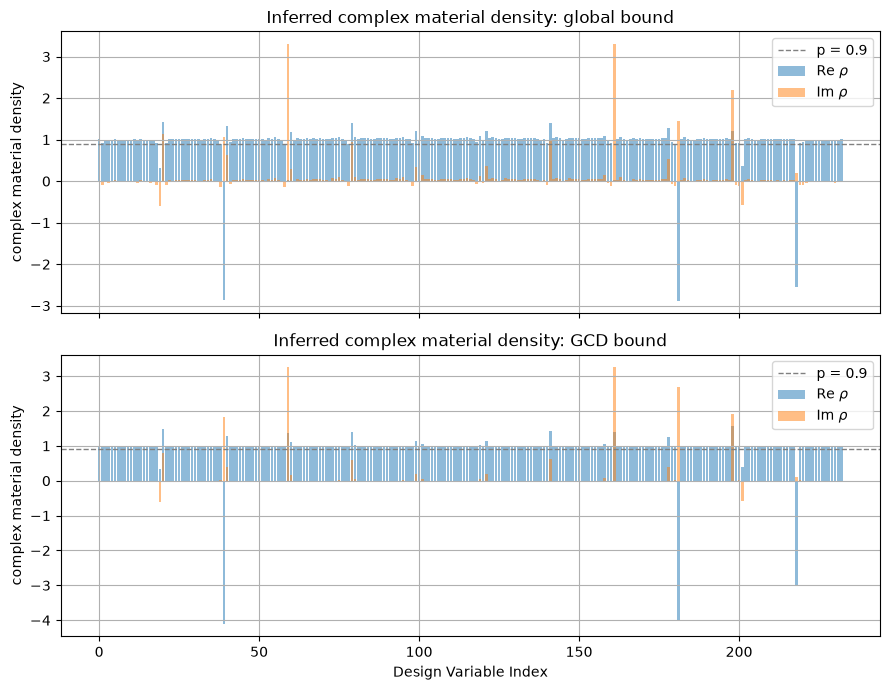

In [269]:
import matplotlib.pyplot as plt

def realizedObj(dens):
    S = np.diag(dens.astype(complex))
    I = np.linalg.solve(Zs*np.eye(Ndes) + S @ Z0, S @ Vinc)
    return evalObj(I)

rhoGlob = complexDensity(QCQP.current_xstar)
rhoGCD = complexDensity(gcd_QCQP.current_xstar)
cases = [("global bound", rhoGlob), ("GCD bound", rhoGCD)]
for name, rho in cases:
    print(f"{name}: Re rho in [{rho.real.min():.3f}, {rho.real.max():.3f}], Im rho in [{rho.imag.min():.3f}, {rho.imag.max():.3f}], "
          f"mean Re rho {rho.real.mean():.3f}, ||Im rho||/||rho|| {np.linalg.norm(rho.imag)/np.linalg.norm(rho):.3e}")
    print(f"    realized objective: clipped {realizedObj(np.clip(rho.real, 0, 1)):.6e} W, "
          f"binary {realizedObj((rho.real > 0.5).astype(float)):.6e} W ({np.sum(rho.real > 0.5)}/{Ndes} filled)")
print(f"full plate {Pfull:.6e} W, uniform rho = {pDens}: {evalObj(Iunif):.6e} W")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, (name, rho) in zip(axes, cases):
    ax.bar(np.arange(Ndes), np.real(rho), alpha=0.5, label=r'Re $\rho$')
    ax.bar(np.arange(Ndes), np.imag(rho), alpha=0.5, label=r'Im $\rho$')
    ax.axhline(pDens, ls='--', c='gray', lw=1, label=f'p = {pDens}')
    ax.set_ylabel('complex material density'); ax.set_title(f'Inferred complex material density: {name}')
    ax.legend(); ax.grid(True)
axes[-1].set_xlabel('Design Variable Index')
plt.tight_layout(); plt.show()

## Rounding

Threshold rounding of the GCD density, $\rho^\mathrm{bin}_i = [\operatorname{Re}\rho_i > t]$, swept over the distinct values of $\operatorname{Re}\rho$ (every distinct binary design reachable by thresholding), each evaluated with the full-wave solve $(Z_s + D_\rho Z_0) I = D_\rho V$.

best threshold 0.9983: 7.346899e-02 W, fill 0.717 (167/233)
threshold 0.5: 4.113846e-02 W, fill 0.979
GCD bound 4.114426e-02 W, full plate 4.114174e-02 W, clipped design 4.113047e-02 W
best binary / GCD bound = 1.785644
density constraint residuals of the best binary design: Im 3.07e-14, Re -8.55e-05, power conservation ['5.62e-11', '1.36e-10']


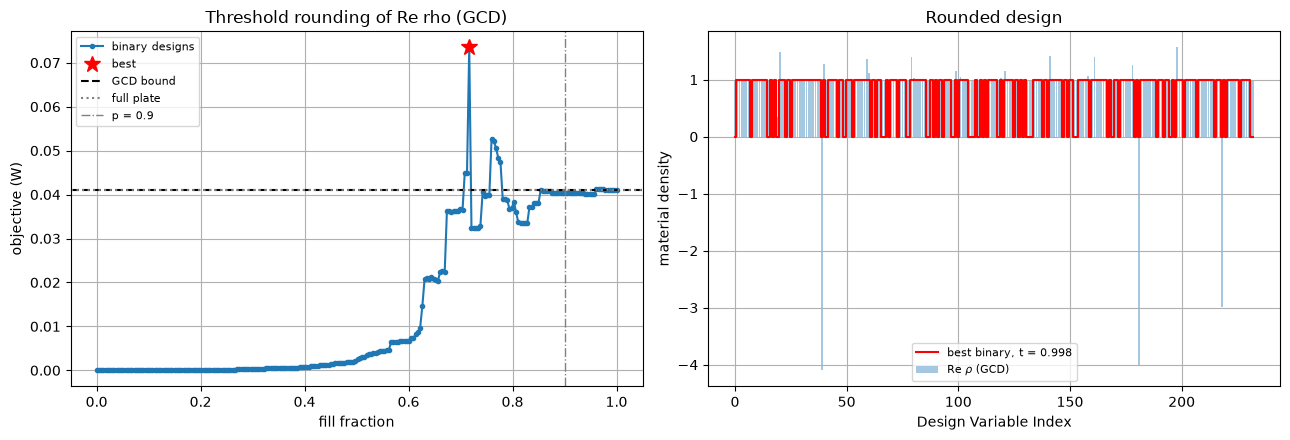

In [270]:
rhoRe = np.real(rhoGCD)
# one threshold between each pair of consecutive sorted values (+ below min / above max)
vals = np.sort(np.unique(rhoRe))
ths = np.concatenate([[vals[0] - 1e-6], 0.5*(vals[1:] + vals[:-1]), [vals[-1] + 1e-6]])
designs = [(rhoRe > t).astype(float) for t in ths]
Pbin = np.array([realizedObj(d) for d in designs])
fill = np.array([d.mean() for d in designs])

ib = int(np.argmax(Pbin))
best = designs[ib]
Ibest = np.linalg.solve(Zs*np.eye(Ndes) + np.diag(best.astype(complex)) @ Z0, best*Vinc)
print(f"best threshold {ths[ib]:.4f}: {Pbin[ib]:.6e} W, fill {fill[ib]:.3f} ({int(best.sum())}/{Ndes})")
print(f"threshold 0.5: {realizedObj((rhoRe > 0.5).astype(float)):.6e} W, fill {np.mean(rhoRe > 0.5):.3f}")
print(f"GCD bound {gcd_QCQP.current_dual:.6e} W, full plate {Pfull:.6e} W, clipped design {realizedObj(np.clip(rhoRe, 0, 1)):.6e} W")
print(f"best binary / GCD bound = {Pbin[ib]/gcd_QCQP.current_dual:.6f}")
print(f"density constraint residuals of the best binary design: Im {genRes(Ibest, BdensIm, sDensIm, cDensIm):.2e}, "
      f"Re {genRes(Ibest, BdensRe, sDensRe, cDensRe):.2e}, power conservation {[f'{projRes(Ibest, Pdiags[:, k]):.2e}' for k in range(Pdiags.shape[1])]}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(fill, Pbin, 'o-', ms=3, label='binary designs')
ax.plot(fill[ib], Pbin[ib], 'r*', ms=12, label='best')
ax.axhline(gcd_QCQP.current_dual, ls='--', c='k', label='GCD bound')
ax.axhline(Pfull, ls=':', c='gray', label='full plate')
ax.axvline(pDens, ls='-.', c='gray', lw=1, label=f'p = {pDens}')
ax.set_xlabel('fill fraction'); ax.set_ylabel('objective (W)'); ax.set_title('Threshold rounding of Re rho (GCD)')
ax.grid(True); ax.legend(fontsize=8)
ax = axes[1]
ax.bar(np.arange(Ndes), rhoRe, alpha=0.4, label=r'Re $\rho$ (GCD)')
ax.step(np.arange(Ndes), best, where='mid', c='r', label=f'best binary, t = {ths[ib]:.3f}')
ax.set_xlabel('Design Variable Index'); ax.set_ylabel('material density'); ax.set_title('Rounded design')
ax.grid(True); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()